Coefficients calculés :
  a (pertes quadratiques) : 1.08506944e-05 (Coordonnée physique cohérente : True)
  b (consommation active) : 9.54861111e-03 (Coordonnée physique cohérente : True)
  c (pertes de veille)    : 4.34027778e-01 (Coordonnée physique cohérente : True)
Rendement résultant au point de longévité (400.0 kW) : 55.65%


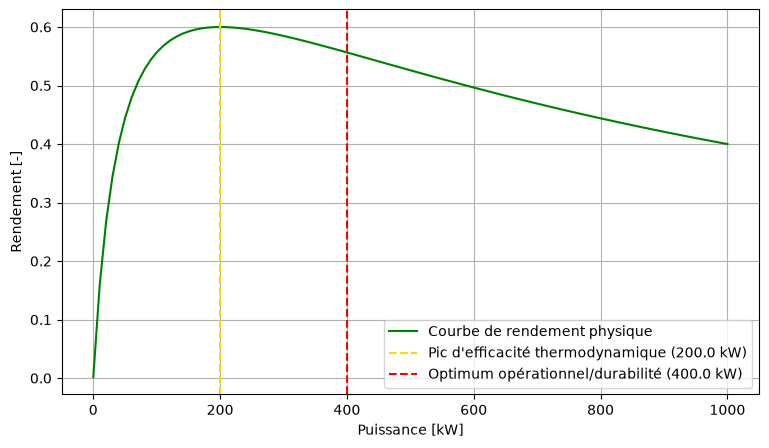

In [1]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 1000.0   # kW
p_nom = 400.0    # kW (point de fonctionnement optimal pour la durée de vie)
LHV = 120.0     # kJ/g

# --- Tes choix physiques ---
p_peak = 200.0   # On force le pic d'efficacité à 40 kW (20% de P_max)
eta_peak = 0.60 # Rendement au pic (60%)
eta_max = 0.40  # Rendement à puissance max (40%)

# --- Calcul des paramètres ---
alpha = p_max / (p_max - p_peak)**2 * (1.0 / eta_max - 1.0 / eta_peak)
beta = 1.0 / eta_peak - 2.0 * alpha * p_peak
gamma = alpha * p_peak ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV

# --- Vérifications qualitatives ---
print("Coefficients calculés :")
print(f"  a (pertes quadratiques) : {a:.8e} (Coordonnée physique cohérente : {a > 0})")
print(f"  b (consommation active) : {b:.8e} (Coordonnée physique cohérente : {b > 0})")
print(f"  c (pertes de veille)    : {c:.8e} (Coordonnée physique cohérente : {c > 0})")

eta_at_nom = p_nom / ((a * p_nom**2 + b * p_nom + c) * LHV)
print(f"Rendement résultant au point de longévité ({p_nom} kW) : {eta_at_nom:.2%}")

# --- Tracé de la courbe de rendement ---
p_vec = np.linspace(0.1, p_max, 100)
plt.figure(figsize=(9, 5))
plt.plot(p_vec, p_vec / (a * p_vec**2 + b * p_vec + c) / LHV, label="Courbe de rendement physique", color="green")
plt.axvline(p_peak, color="gold", linestyle="--", label=f"Pic d'efficacité thermodynamique ({p_peak} kW)")
plt.axvline(p_nom, color="red", linestyle="--", label=f"Optimum opérationnel/durabilité ({p_nom} kW)")
plt.xlabel("Puissance [kW]")
plt.ylabel("Rendement [-]")
plt.legend()
plt.grid(True)
plt.show()